
# Attention 與 Bidirectional Encoder：NumPy Vanilla 實作

本 Notebook 依據「Attention 與 Bidirectional Encoder 的數學推導」實作一個小型的 **RNN-based Seq2Seq with Additive Attention + Bidirectional Encoder**。

限制條件：

- 僅使用 `numpy` 實作模型、forward、backward、參數更新。
- Token 處理自行撰寫。
- 圖表使用 `matplotlib`。
- 資料集由程式生成。
- 目標是讓讀者看到數學公式如何對應到實際程式，而不是追求大型模型效能。

本範例任務：

> 輸入一串 token，模型要輸出反轉後的序列。

例如：

```text
input  : A B C D
target : D C B A
```

這個任務很適合展示 attention，因為 decoder 每一步理論上應該關注輸入序列中對應的位置。


## 程式碼風格說明

本 Notebook 採用以下原則：

> 核心數學與模型流程避免過度語法糖；一般資料處理、列印、檢查與輔助函式可使用 Python 慣用寫法，以可讀性為優先。

因此，RNN time step、attention score、softmax backward、BPTT、梯度累積與參數更新等核心數學流程會保留較展開的寫法，方便對照數學式。資料處理、詞彙表建立、padding、列印與解碼輔助函式則可使用 `enumerate`、list comprehension、dictionary comprehension、`.get()` 等常見 Python 寫法，避免重複樣板干擾閱讀。


In [4]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
random.seed(7)


## 1. Token 處理與資料集生成

Seq2Seq 模型不能直接讀取字串，因此需要把 token 轉成整數 id，再轉成 one-hot 向量。

這裡建立一個非常小的 詞彙表（vocabulary）：

- `<PAD>`：padding token，本範例為了簡化不使用 batch padding。
- `<SOS>`：decoder 起始 token。
- `<EOS>`：decoder 結束 token。
- `A` 到 `H`：一般內容 token。

訓練資料由程式隨機生成，輸出目標為輸入序列反轉後加上 `<EOS>`。


In [5]:
# 定義特殊 token，用於 padding、序列開始與序列結束。
PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"

# 定義可出現在資料中的基礎 token。
base_tokens = ["A", "B", "C", "D", "E", "F", "G", "H"]

# 將特殊 token 放在 vocabulary 前段，方便固定其 id。
vocab = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + base_tokens

# 建立 token 與 id 的雙向對照表。
token_to_id = {token: index for index, token in enumerate(vocab)}
id_to_token = {index: token for index, token in enumerate(vocab)}

# 取出常用特殊 token 的 id，並記錄 vocabulary 大小。
PAD_ID = token_to_id[PAD_TOKEN]
SOS_ID = token_to_id[SOS_TOKEN]
EOS_ID = token_to_id[EOS_TOKEN]
VOCAB_SIZE = len(vocab)

def encode_tokens(tokens):
    """將 token 序列轉換成對應的 id 序列。"""
    return [token_to_id[token] for token in tokens]

def decode_ids(ids):
    """將 id 序列轉回對應的 token 序列。"""
    return [id_to_token[int(token_id)] for token_id in ids]

def one_hot(token_id, vocab_size):
    """建立指定 token id 的 one-hot 向量。"""
    vector = np.zeros((vocab_size, 1))
    vector[int(token_id), 0] = 1.0
    return vector

def make_example(min_len=3, max_len=6):
    """隨機產生一筆序列反轉任務的訓練範例。"""
    length = random.randint(min_len, max_len)

    # source 是由基礎 token 隨機組成的序列。
    source_tokens = [random.choice(base_tokens) for _ in range(length)]

    # target 是 source 的反向序列，並在結尾加上 EOS token。
    target_tokens = list(reversed(source_tokens)) + [EOS_TOKEN]

    return encode_tokens(source_tokens), encode_tokens(target_tokens)

def make_dataset(n):
    """產生指定筆數的資料集。"""
    return [make_example() for _ in range(n)]

# 建立訓練資料與測試資料。
train_data = make_dataset(600)
test_data = make_dataset(80)

# 印出 vocabulary 與第一筆訓練資料的可讀範例。
print("Vocabulary:", vocab)
print("Example source:", decode_ids(train_data[0][0]))
print("Example target:", decode_ids(train_data[0][1]))

Vocabulary: ['<PAD>', '<SOS>', '<EOS>', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
Example source: ['C', 'G', 'A', 'B', 'B']
Example target: ['B', 'B', 'A', 'G', 'C', '<EOS>']



## 2. 數學對應：Forward Pass

### Bidirectional Encoder

Forward RNN：

$$
\overrightarrow{h}_t = \tanh(W_{xh}^{\rightarrow} x_t + W_{hh}^{\rightarrow}\overrightarrow{h}_{t-1} + b_h^{\rightarrow})
$$

Backward RNN：

$$
\overleftarrow{h}_t = \tanh(W_{xh}^{\leftarrow} x_t + W_{hh}^{\leftarrow}\overleftarrow{h}_{t+1} + b_h^{\leftarrow})
$$

合併：

$$
h_t^{enc} = [\overrightarrow{h}_t ; \overleftarrow{h}_t]
$$

### Additive Attention

$$
e_{t,i} = v_a^T \tanh(W_a s_{t-1} + U_a h_i^{enc})
$$

$$
\alpha_{t,i} = \frac{\exp(e_{t,i})}{\sum_j \exp(e_{t,j})}
$$

$$
c_t = \sum_i \alpha_{t,i}h_i^{enc}
$$

### Decoder 與輸出

$$
s_t = \tanh(W_y y_{t-1}^{in} + W_s s_{t-1} + W_c c_t + b_s)
$$

$$
\hat{y}_t = \text{softmax}(W_o[s_t;c_t] + b_o)
$$


In [6]:
def softmax(logits):
    """將 logits 轉換為機率分布。"""
    # logits shape: (V, 1) or (T, 1)
    shifted = logits - np.max(logits)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values)

def cross_entropy_from_probs(probs, target_id):
    """根據目標 token id 計算 cross entropy loss。"""
    eps = 1e-12
    return -math.log(float(probs[int(target_id), 0]) + eps)

def init_matrix(rows, cols):
    """使用 Xavier-like initialization 建立權重矩陣。"""
    # Xavier-like initialization
    limit = math.sqrt(6.0 / (rows + cols))
    return np.random.uniform(-limit, limit, (rows, cols))

def init_params(vocab_size, embed_dim, enc_hidden_dim, dec_hidden_dim, attn_dim):
    """初始化 embedding、encoder、attention、decoder 與輸出層參數。"""
    params = {}

    # Embedding matrix: x_t = E one_hot(token)
    params["E"] = init_matrix(embed_dim, vocab_size)

    # Forward encoder 的 recurrent 參數。
    params["Wxh_f"] = init_matrix(enc_hidden_dim, embed_dim)
    params["Whh_f"] = init_matrix(enc_hidden_dim, enc_hidden_dim)
    params["bh_f"] = np.zeros((enc_hidden_dim, 1))

    # Backward encoder 的 recurrent 參數。
    params["Wxh_b"] = init_matrix(enc_hidden_dim, embed_dim)
    params["Whh_b"] = init_matrix(enc_hidden_dim, enc_hidden_dim)
    params["bh_b"] = np.zeros((enc_hidden_dim, 1))

    # 雙向 encoder 會串接 forward 與 backward hidden state。
    enc_concat_dim = 2 * enc_hidden_dim

    # Decoder initial state 的線性轉換參數。
    params["W_init"] = init_matrix(dec_hidden_dim, enc_concat_dim)
    params["b_init"] = np.zeros((dec_hidden_dim, 1))

    # Attention score 計算所需的參數。
    params["Wa"] = init_matrix(attn_dim, dec_hidden_dim)
    params["Ua"] = init_matrix(attn_dim, enc_concat_dim)
    params["va"] = init_matrix(attn_dim, 1)

    # Decoder recurrent state 更新所需的參數。
    params["Wy"] = init_matrix(dec_hidden_dim, embed_dim)
    params["Ws"] = init_matrix(dec_hidden_dim, dec_hidden_dim)
    params["Wc"] = init_matrix(dec_hidden_dim, enc_concat_dim)
    params["bs"] = np.zeros((dec_hidden_dim, 1))

    # Output projection，將 decoder state 與 context 轉成 vocabulary logits。
    params["Wo"] = init_matrix(vocab_size, dec_hidden_dim + enc_concat_dim)
    params["bo"] = np.zeros((vocab_size, 1))

    return params

def zero_grads_like(params):
    """建立與參數同形狀的零梯度容器。"""
    return {key: np.zeros_like(value) for key, value in params.items()}

def embed_token(params, token_id):
    """將 token id 轉成 one-hot 後，再投影成 embedding 向量。"""
    x_one_hot = one_hot(token_id, VOCAB_SIZE)
    embedding = np.dot(params["E"], x_one_hot)
    return embedding, x_one_hot


## 3. Forward 實作

`forward_pass` 會同時計算：

1. encoder 的雙向 hidden states。
2. decoder 每一步的 attention。
3. 每一步的預測機率。
4. cross-entropy loss。

訓練時使用 teacher forcing：

$$
y_{t-1}^{in} = y_{t-1}^{true}
$$

其中第一步 decoder input 是 `<SOS>`。


In [7]:
def forward_pass(params, source_ids, target_ids):
    """執行模型的 forward pass，並保存 backward pass 需要的中間結果。"""
    cache = {}

    Tx = len(source_ids)
    Ty = len(target_ids)

    source_embeddings = []
    source_one_hots = []

    # 將 source token id 轉成 embedding 與 one-hot 表示。
    for i in range(Tx):
        emb, oh = embed_token(params, source_ids[i])
        source_embeddings.append(emb)
        source_one_hots.append(oh)

    # Forward encoder
    h_f = []
    a_f = []
    prev_h = np.zeros((params["Whh_f"].shape[0], 1))

    # 由左到右計算 forward encoder hidden state。
    for i in range(Tx):
        a = np.dot(params["Wxh_f"], source_embeddings[i]) + np.dot(params["Whh_f"], prev_h) + params["bh_f"]
        h = np.tanh(a)

        a_f.append(a)
        h_f.append(h)
        prev_h = h

    # Backward encoder
    h_b = [None] * Tx
    a_b = [None] * Tx
    next_h = np.zeros((params["Whh_b"].shape[0], 1))

    # 由右到左計算 backward encoder hidden state。
    for i in range(Tx - 1, -1, -1):
        a = np.dot(params["Wxh_b"], source_embeddings[i]) + np.dot(params["Whh_b"], next_h) + params["bh_b"]
        h = np.tanh(a)

        a_b[i] = a
        h_b[i] = h
        next_h = h

    # Concatenate bidirectional states
    h_enc = []
    for i in range(Tx):
        h_enc.append(np.vstack((h_f[i], h_b[i])))

    # Initial decoder state: tanh(W_init [h_f_last ; h_b_first] + b_init)
    enc_summary = np.vstack((h_f[Tx - 1], h_b[0]))
    a_init = np.dot(params["W_init"], enc_summary) + params["b_init"]
    s_prev = np.tanh(a_init)

    # 建立 decoder input；第一步使用 SOS，後續使用前一個 target token。
    decoder_inputs = [SOS_ID]
    for t in range(Ty - 1):
        decoder_inputs.append(target_ids[t])

    decoder_input_embeddings = []
    decoder_input_one_hots = []

    # 將 decoder input token id 轉成 embedding 與 one-hot 表示。
    for token_id in decoder_inputs:
        emb, oh = embed_token(params, token_id)
        decoder_input_embeddings.append(emb)
        decoder_input_one_hots.append(oh)

    # 保存 decoder 各時間步的中間結果。
    s_list = []
    a_dec_list = []
    c_list = []
    alpha_list = []
    e_list = []
    z_list = []
    output_concat_list = []
    logits_list = []
    probs_list = []

    loss = 0.0

    for t in range(Ty):
        # Additive attention
        e_values = []
        z_values = []

        # 對每個 encoder state 計算 attention score。
        for i in range(Tx):
            z = np.tanh(np.dot(params["Wa"], s_prev) + np.dot(params["Ua"], h_enc[i]))
            e = np.dot(params["va"].T, z)

            z_values.append(z)
            e_values.append(e)

        e_vec = np.zeros((Tx, 1))
        for i in range(Tx):
            e_vec[i, 0] = e_values[i][0, 0]

        # 將 attention score 正規化為權重。
        alpha = softmax(e_vec)

        # 依 attention 權重加權合成 context vector。
        c = np.zeros_like(h_enc[0])
        for i in range(Tx):
            c = c + alpha[i, 0] * h_enc[i]

        # Decoder recurrence
        a_dec = (
            np.dot(params["Wy"], decoder_input_embeddings[t])
            + np.dot(params["Ws"], s_prev)
            + np.dot(params["Wc"], c)
            + params["bs"]
        )
        s = np.tanh(a_dec)

        # 將 decoder state 與 context 串接後投影成 vocabulary logits。
        output_concat = np.vstack((s, c))
        logits = np.dot(params["Wo"], output_concat) + params["bo"]
        probs = softmax(logits)

        # 累加目前時間步的 cross entropy loss。
        loss = loss + cross_entropy_from_probs(probs, target_ids[t])

        s_list.append(s)
        a_dec_list.append(a_dec)
        c_list.append(c)
        alpha_list.append(alpha)
        e_list.append(e_vec)
        z_list.append(z_values)
        output_concat_list.append(output_concat)
        logits_list.append(logits)
        probs_list.append(probs)

        s_prev = s

    # 以 target 長度計算平均 loss。
    loss = loss / Ty

    # 保存輸入、encoder、decoder 與 attention 的中間結果。
    cache["source_ids"] = source_ids
    cache["target_ids"] = target_ids
    cache["Tx"] = Tx
    cache["Ty"] = Ty
    cache["source_embeddings"] = source_embeddings
    cache["source_one_hots"] = source_one_hots
    cache["h_f"] = h_f
    cache["a_f"] = a_f
    cache["h_b"] = h_b
    cache["a_b"] = a_b
    cache["h_enc"] = h_enc
    cache["enc_summary"] = enc_summary
    cache["a_init"] = a_init
    cache["decoder_inputs"] = decoder_inputs
    cache["decoder_input_embeddings"] = decoder_input_embeddings
    cache["decoder_input_one_hots"] = decoder_input_one_hots
    cache["s_list"] = s_list
    cache["a_dec_list"] = a_dec_list
    cache["c_list"] = c_list
    cache["alpha_list"] = alpha_list
    cache["e_list"] = e_list
    cache["z_list"] = z_list
    cache["output_concat_list"] = output_concat_list
    cache["logits_list"] = logits_list
    cache["probs_list"] = probs_list

    return loss, cache


## 4. Backward Pass：手寫 BPTT

本節會把 cross-entropy loss 的梯度一路反傳到所有參數。

### Softmax + Cross Entropy

若：

$$
\hat{y}_t = \text{softmax}(o_t)
$$

則：

$$
\frac{\partial L_t}{\partial o_t} = \hat{y}_t - y_t
$$

由於本程式 loss 對時間步取平均，所以每一步梯度再除以 `Ty`。

### Attention 的主要反傳路徑

context vector：

$$
c_t = \sum_i \alpha_{t,i} h_i^{enc}
$$

所以梯度會分成：

1. 由 `c_t` 直接傳回每個 `h_enc[i]`。
2. 經由 `alpha`、`e`、`z` 再傳回 attention 參數與 encoder states。


In [8]:

def backward_pass(params, cache):
    grads = zero_grads_like(params)

    Tx = cache["Tx"]
    Ty = cache["Ty"]

    enc_hidden_dim = params["Whh_f"].shape[0]
    dec_hidden_dim = params["Ws"].shape[0]

    # Gradient containers for hidden states
    dh_enc = []
    for _ in range(Tx):
        dh_enc.append(np.zeros_like(cache["h_enc"][0]))

    dh_f_extra = []
    dh_b_extra = []
    for _ in range(Tx):
        dh_f_extra.append(np.zeros_like(cache["h_f"][0]))
        dh_b_extra.append(np.zeros_like(cache["h_b"][0]))

    ds_from_future = np.zeros((dec_hidden_dim, 1))

    # This stores gradients that flow from attention at step t+1 to s_t
    ds_attention = []
    for _ in range(Ty):
        ds_attention.append(np.zeros((dec_hidden_dim, 1)))

    # Decoder BPTT runs backward in time
    for t in range(Ty - 1, -1, -1):
        target_id = cache["target_ids"][t]

        # d logits = probs - one_hot(target)
        dlogits = np.copy(cache["probs_list"][t])
        dlogits[int(target_id), 0] = dlogits[int(target_id), 0] - 1.0
        dlogits = dlogits / Ty

        output_concat = cache["output_concat_list"][t]
        grads["Wo"] = grads["Wo"] + np.dot(dlogits, output_concat.T)
        grads["bo"] = grads["bo"] + dlogits

        doutput_concat = np.dot(params["Wo"].T, dlogits)

        ds = doutput_concat[0:dec_hidden_dim, :]
        dc = doutput_concat[dec_hidden_dim:, :]

        ds = ds + ds_from_future + ds_attention[t]

        s = cache["s_list"][t]
        da_dec = ds * (1.0 - s * s)

        y_emb = cache["decoder_input_embeddings"][t]
        s_prev = None

        if t == 0:
            s_prev = np.tanh(cache["a_init"])
        else:
            s_prev = cache["s_list"][t - 1]

        c = cache["c_list"][t]

        grads["Wy"] = grads["Wy"] + np.dot(da_dec, y_emb.T)
        grads["Ws"] = grads["Ws"] + np.dot(da_dec, s_prev.T)
        grads["Wc"] = grads["Wc"] + np.dot(da_dec, c.T)
        grads["bs"] = grads["bs"] + da_dec

        # Gradients to previous decoder state and context
        ds_prev_total = np.dot(params["Ws"].T, da_dec)
        dc = dc + np.dot(params["Wc"].T, da_dec)

        # Decoder input embedding gradient
        dy_emb = np.dot(params["Wy"].T, da_dec)
        grads["E"] = grads["E"] + np.dot(dy_emb, cache["decoder_input_one_hots"][t].T)

        # Attention backward
        alpha = cache["alpha_list"][t]

        dalpha = np.zeros((Tx, 1))

        # c = sum_i alpha_i * h_i
        for i in range(Tx):
            h_i = cache["h_enc"][i]
            dh_enc[i] = dh_enc[i] + alpha[i, 0] * dc
            dalpha[i, 0] = np.dot(dc.T, h_i)[0, 0]

        # softmax backward: de = alpha * (dalpha - sum_j dalpha_j alpha_j)
        weighted_sum = float(np.sum(dalpha * alpha))
        de = np.zeros((Tx, 1))

        for i in range(Tx):
            de[i, 0] = alpha[i, 0] * (dalpha[i, 0] - weighted_sum)

        # e_i = va^T z_i
        # z_i = tanh(Wa s_prev + Ua h_i)
        for i in range(Tx):
            z = cache["z_list"][t][i]
            dz = de[i, 0] * params["va"]
            da_attn = dz * (1.0 - z * z)

            grads["va"] = grads["va"] + de[i, 0] * z
            grads["Wa"] = grads["Wa"] + np.dot(da_attn, s_prev.T)
            grads["Ua"] = grads["Ua"] + np.dot(da_attn, cache["h_enc"][i].T)

            ds_prev_total = ds_prev_total + np.dot(params["Wa"].T, da_attn)
            dh_enc[i] = dh_enc[i] + np.dot(params["Ua"].T, da_attn)

        # Move gradient to previous decoder time step
        if t > 0:
            ds_from_future = ds_prev_total
        else:
            # t = 0 的 s_prev 是 decoder initial state
            da_init = ds_prev_total * (1.0 - np.tanh(cache["a_init"]) * np.tanh(cache["a_init"]))
            grads["W_init"] = grads["W_init"] + np.dot(da_init, cache["enc_summary"].T)
            grads["b_init"] = grads["b_init"] + da_init

            denc_summary = np.dot(params["W_init"].T, da_init)

            # enc_summary = [h_f_last ; h_b_first]
            dh_f_extra[Tx - 1] = dh_f_extra[Tx - 1] + denc_summary[0:enc_hidden_dim, :]
            dh_b_extra[0] = dh_b_extra[0] + denc_summary[enc_hidden_dim:, :]

            ds_from_future = np.zeros_like(ds_from_future)

    # Split encoder gradient into forward and backward halves
    for i in range(Tx):
        dh_f_extra[i] = dh_f_extra[i] + dh_enc[i][0:enc_hidden_dim, :]
        dh_b_extra[i] = dh_b_extra[i] + dh_enc[i][enc_hidden_dim:, :]

    # Forward encoder BPTT
    dh_next = np.zeros((enc_hidden_dim, 1))

    for i in range(Tx - 1, -1, -1):
        dh_total = dh_f_extra[i] + dh_next
        h = cache["h_f"][i]
        da = dh_total * (1.0 - h * h)

        x_emb = cache["source_embeddings"][i]

        if i == 0:
            h_prev = np.zeros((enc_hidden_dim, 1))
        else:
            h_prev = cache["h_f"][i - 1]

        grads["Wxh_f"] = grads["Wxh_f"] + np.dot(da, x_emb.T)
        grads["Whh_f"] = grads["Whh_f"] + np.dot(da, h_prev.T)
        grads["bh_f"] = grads["bh_f"] + da

        dx_emb = np.dot(params["Wxh_f"].T, da)
        grads["E"] = grads["E"] + np.dot(dx_emb, cache["source_one_hots"][i].T)

        dh_next = np.dot(params["Whh_f"].T, da)

    # Backward encoder BPTT
    # backward recurrence uses h_b[i + 1], so gradient flows from smaller i to larger i
    dh_prev_in_backward_time = np.zeros((enc_hidden_dim, 1))

    for i in range(0, Tx):
        dh_total = dh_b_extra[i] + dh_prev_in_backward_time
        h = cache["h_b"][i]
        da = dh_total * (1.0 - h * h)

        x_emb = cache["source_embeddings"][i]

        if i == Tx - 1:
            h_next = np.zeros((enc_hidden_dim, 1))
        else:
            h_next = cache["h_b"][i + 1]

        grads["Wxh_b"] = grads["Wxh_b"] + np.dot(da, x_emb.T)
        grads["Whh_b"] = grads["Whh_b"] + np.dot(da, h_next.T)
        grads["bh_b"] = grads["bh_b"] + da

        dx_emb = np.dot(params["Wxh_b"].T, da)
        grads["E"] = grads["E"] + np.dot(dx_emb, cache["source_one_hots"][i].T)

        dh_prev_in_backward_time = np.dot(params["Whh_b"].T, da)

    return grads



## 5. 參數優化

這裡使用 vanilla SGD：

$$
\theta \leftarrow \theta - \eta \frac{\partial L}{\partial \theta}
$$

實務上 RNN 容易出現梯度爆炸，因此加入 global gradient clipping：

$$
g \leftarrow g \cdot \frac{\text{clip}}{\|g\|}
$$

當梯度 norm 大於指定上限時才縮放。


In [9]:

def global_grad_norm(grads):
    total = 0.0
    for key in grads:
        total = total + float(np.sum(grads[key] * grads[key]))
    return math.sqrt(total)

def clip_grads(grads, max_norm):
    norm = global_grad_norm(grads)

    if norm > max_norm:
        scale = max_norm / (norm + 1e-12)
        for key in grads:
            grads[key] = grads[key] * scale

    return norm

def sgd_update(params, grads, learning_rate):
    for key in params:
        params[key] = params[key] - learning_rate * grads[key]



## 6. 推論與評估函式

訓練時 decoder 使用 teacher forcing；推論時沒有 target token，因此每一步都把上一個模型預測 token 當成下一步輸入。

這裡也提供 average loss 與 exact match accuracy。


In [10]:

def predict(params, source_ids, max_len=10):
    Tx = len(source_ids)

    # 這裡直接重用前面模型的 encoder 邏輯，接著用 greedy decoding 逐步產生法文 token。
    source_embeddings = []
    for i in range(Tx):
        emb, _ = embed_token(params, source_ids[i])
        source_embeddings.append(emb)

    h_f = []
    prev_h = np.zeros((params["Whh_f"].shape[0], 1))

    for i in range(Tx):
        a = np.dot(params["Wxh_f"], source_embeddings[i]) + np.dot(params["Whh_f"], prev_h) + params["bh_f"]
        h = np.tanh(a)
        h_f.append(h)
        prev_h = h

    h_b = [None] * Tx
    next_h = np.zeros((params["Whh_b"].shape[0], 1))

    for i in range(Tx - 1, -1, -1):
        a = np.dot(params["Wxh_b"], source_embeddings[i]) + np.dot(params["Whh_b"], next_h) + params["bh_b"]
        h = np.tanh(a)
        h_b[i] = h
        next_h = h

    h_enc = []
    for i in range(Tx):
        h_enc.append(np.vstack((h_f[i], h_b[i])))

    enc_summary = np.vstack((h_f[Tx - 1], h_b[0]))
    s_prev = np.tanh(np.dot(params["W_init"], enc_summary) + params["b_init"])

    current_id = SOS_ID
    predicted_ids = []
    attentions = []

    for _ in range(max_len):
        y_emb, _ = embed_token(params, current_id)

        e_vec = np.zeros((Tx, 1))
        z_values = []

        for i in range(Tx):
            z = np.tanh(np.dot(params["Wa"], s_prev) + np.dot(params["Ua"], h_enc[i]))
            e = np.dot(params["va"].T, z)
            e_vec[i, 0] = e[0, 0]
            z_values.append(z)

        alpha = softmax(e_vec)

        c = np.zeros_like(h_enc[0])
        for i in range(Tx):
            c = c + alpha[i, 0] * h_enc[i]

        a_dec = (
            np.dot(params["Wy"], y_emb)
            + np.dot(params["Ws"], s_prev)
            + np.dot(params["Wc"], c)
            + params["bs"]
        )
        s = np.tanh(a_dec)

        output_concat = np.vstack((s, c))
        logits = np.dot(params["Wo"], output_concat) + params["bo"]
        probs = softmax(logits)

        next_id = int(np.argmax(probs[:, 0]))
        predicted_ids.append(next_id)
        attentions.append(alpha[:, 0].copy())

        if next_id == EOS_ID:
            break

        current_id = next_id
        s_prev = s

    return predicted_ids, attentions

def evaluate_loss(params, dataset):
    total_loss = 0.0

    for source_ids, target_ids in dataset:
        loss, _ = forward_pass(params, source_ids, target_ids)
        total_loss = total_loss + loss

    return total_loss / len(dataset)

def evaluate_exact_match(params, dataset):
    correct = 0

    for source_ids, target_ids in dataset:
        pred_ids, _ = predict(params, source_ids, max_len=len(target_ids) + 2)

        # Trim after EOS for fair comparison
        trimmed = []
        for token_id in pred_ids:
            trimmed.append(token_id)
            if token_id == EOS_ID:
                break

        if trimmed == target_ids:
            correct = correct + 1

    return correct / len(dataset)



## 7. 訓練函式

每一筆資料執行：

1. forward pass。
2. backward pass。
3. gradient clipping。
4. SGD update。

這是逐筆 stochastic gradient descent。為了讓範例容易閱讀，沒有使用 mini-batch。


In [11]:

def train(params, train_dataset, valid_dataset, epochs, learning_rate, clip_norm):
    train_losses = []
    valid_losses = []
    valid_accuracies = []

    for epoch in range(epochs):
        random.shuffle(train_dataset)

        total_loss = 0.0
        total_grad_norm = 0.0

        for source_ids, target_ids in train_dataset:
            loss, cache = forward_pass(params, source_ids, target_ids)
            grads = backward_pass(params, cache)

            grad_norm = clip_grads(grads, clip_norm)
            sgd_update(params, grads, learning_rate)

            total_loss = total_loss + loss
            total_grad_norm = total_grad_norm + grad_norm

        avg_train_loss = total_loss / len(train_dataset)
        avg_valid_loss = evaluate_loss(params, valid_dataset)
        valid_acc = evaluate_exact_match(params, valid_dataset)

        train_losses.append(avg_train_loss)
        valid_losses.append(avg_valid_loss)
        valid_accuracies.append(valid_acc)

        print(
            "epoch",
            epoch + 1,
            "train_loss",
            round(avg_train_loss, 4),
            "valid_loss",
            round(avg_valid_loss, 4),
            "valid_exact_match",
            round(valid_acc, 4),
            "avg_grad_norm",
            round(total_grad_norm / len(train_dataset), 4)
        )

    history = {
        "train_loss": train_losses,
        "valid_loss": valid_losses,
        "valid_accuracy": valid_accuracies
    }

    return history



## 8. 開始訓練

模型維度刻意設小，讓 vanilla NumPy 能在一般環境中執行。

若要更穩定，可增加 `epochs` 或調整 `learning_rate`。


In [12]:

params = init_params(
    vocab_size=VOCAB_SIZE,
    embed_dim=16,
    enc_hidden_dim=24,
    dec_hidden_dim=32,
    attn_dim=24
)

history = train(
    params=params,
    train_dataset=train_data,
    valid_dataset=test_data,
    epochs=25,
    learning_rate=0.04,
    clip_norm=5.0
)


epoch 1 train_loss 1.5423 valid_loss 0.9215 valid_exact_match 0.1625 avg_grad_norm 2.6723
epoch 2 train_loss 0.4864 valid_loss 0.253 valid_exact_match 0.675 avg_grad_norm 3.0239
epoch 3 train_loss 0.0791 valid_loss 0.0449 valid_exact_match 0.975 avg_grad_norm 1.3044
epoch 4 train_loss 0.0206 valid_loss 0.0168 valid_exact_match 1.0 avg_grad_norm 0.3611
epoch 5 train_loss 0.0093 valid_loss 0.0109 valid_exact_match 1.0 avg_grad_norm 0.1462
epoch 6 train_loss 0.0062 valid_loss 0.0079 valid_exact_match 1.0 avg_grad_norm 0.0977
epoch 7 train_loss 0.0047 valid_loss 0.0065 valid_exact_match 1.0 avg_grad_norm 0.0741
epoch 8 train_loss 0.0037 valid_loss 0.0054 valid_exact_match 1.0 avg_grad_norm 0.0607
epoch 9 train_loss 0.0031 valid_loss 0.0045 valid_exact_match 1.0 avg_grad_norm 0.0497
epoch 10 train_loss 0.0026 valid_loss 0.0039 valid_exact_match 1.0 avg_grad_norm 0.0439
epoch 11 train_loss 0.0023 valid_loss 0.0035 valid_exact_match 1.0 avg_grad_norm 0.0384
epoch 12 train_loss 0.002 valid_los


## 9. 評估 loss 圖表

若訓練有效，train loss 和 validation loss 應逐步下降。


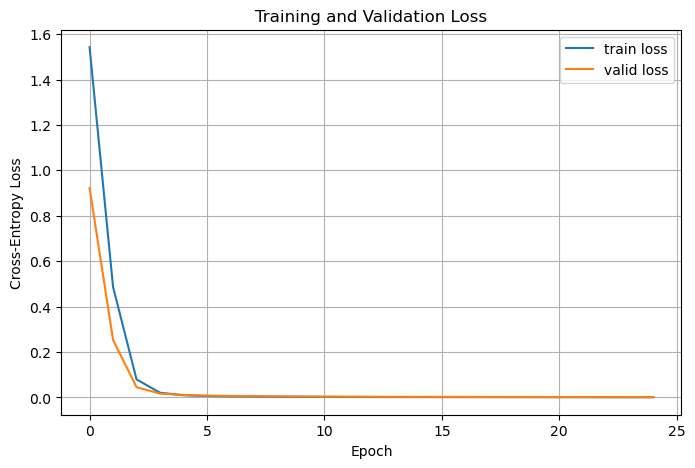

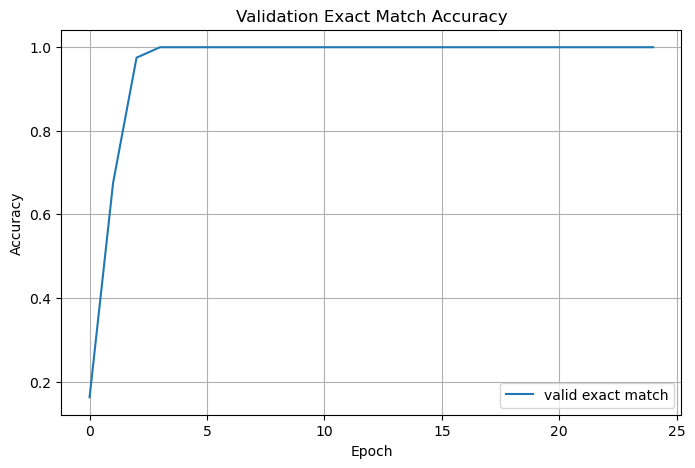

In [13]:

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["valid_loss"], label="valid loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["valid_accuracy"], label="valid exact match")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Exact Match Accuracy")
plt.legend()
plt.grid(True)
plt.show()



## 10. 簡單測試訓練效果

下面隨機取測試資料，顯示：

- input sequence
- target sequence
- predicted sequence

如果模型學到反轉規則，predicted 應接近 target。


In [14]:

for index in range(10):
    source_ids, target_ids = test_data[index]
    pred_ids, attn = predict(params, source_ids, max_len=len(target_ids) + 2)

    print("input    :", " ".join(decode_ids(source_ids)))
    print("target   :", " ".join(decode_ids(target_ids)))
    print("predicted:", " ".join(decode_ids(pred_ids)))
    print("-" * 50)


input    : B D B A G D
target   : D G A B D B <EOS>
predicted: D G A B D B <EOS>
--------------------------------------------------
input    : H G C A C
target   : C A C G H <EOS>
predicted: C A C G H <EOS>
--------------------------------------------------
input    : C H E
target   : E H C <EOS>
predicted: E H C <EOS>
--------------------------------------------------
input    : F C E E
target   : E E C F <EOS>
predicted: E E C F <EOS>
--------------------------------------------------
input    : D C D G A
target   : A G D C D <EOS>
predicted: A G D C D <EOS>
--------------------------------------------------
input    : G C E D B
target   : B D E C G <EOS>
predicted: B D E C G <EOS>
--------------------------------------------------
input    : H C C G
target   : G C C H <EOS>
predicted: G C C H <EOS>
--------------------------------------------------
input    : G B A F B
target   : B F A B G <EOS>
predicted: B F A B G <EOS>
--------------------------------------------------
input    :


## 11. Attention 權重視覺化

對反轉任務而言，理想情況下：

- decoder 第 1 步應關注 input 最後一個 token。
- decoder 第 2 步應關注 input 倒數第二個 token。
- 以此類推。

注意力矩陣的列代表 decoder step，欄代表 encoder input position。


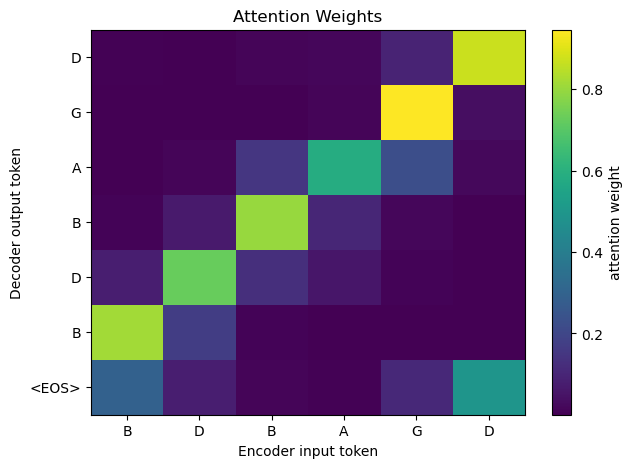

input    : B D B A G D
target   : D G A B D B <EOS>
predicted: D G A B D B <EOS>


In [15]:

source_ids, target_ids = test_data[0]
pred_ids, attentions = predict(params, source_ids, max_len=len(target_ids) + 2)

attention_matrix = np.array(attentions)

plt.figure(figsize=(7, 5))
plt.imshow(attention_matrix, aspect="auto")
plt.colorbar(label="attention weight")
plt.xticks(range(len(source_ids)), decode_ids(source_ids))
plt.yticks(range(len(pred_ids)), decode_ids(pred_ids))
plt.xlabel("Encoder input token")
plt.ylabel("Decoder output token")
plt.title("Attention Weights")
plt.show()

print("input    :", " ".join(decode_ids(source_ids)))
print("target   :", " ".join(decode_ids(target_ids)))
print("predicted:", " ".join(decode_ids(pred_ids)))



## 12. 推導與程式的對應整理

| 數學符號 | 程式變數 |
|---|---|
| $x_t$ | `source_embeddings[i]` |
| $\overrightarrow{h}_t$ | `h_f[i]` |
| $\overleftarrow{h}_t$ | `h_b[i]` |
| $h_t^{enc}$ | `h_enc[i]` |
| $s_t$ | `s_list[t]` |
| $e_{t,i}$ | `e_vec[i, 0]` |
| $\alpha_{t,i}$ | `alpha[i, 0]` |
| $c_t$ | `c_list[t]` |
| $o_t$ | `logits_list[t]` |
| $\hat{y}_t$ | `probs_list[t]` |
| $\frac{\partial L}{\partial o_t}$ | `dlogits` |
| $\frac{\partial L}{\partial W_o}$ | `grads["Wo"]` |
| $\frac{\partial L}{\partial W_a}$ | `grads["Wa"]` |
| $\frac{\partial L}{\partial U_a}$ | `grads["Ua"]` |

這份 Notebook 的重點不是使用深度學習框架，而是讓每一個矩陣乘法、softmax、cross-entropy、BPTT 和參數更新都能直接對照到數學式。



# 13. 英文到法文翻譯測試：使用 `Data/fra.txt`

前面的範例任務是「反轉序列」，其好處是容易檢查 attention 是否學到對齊關係。

本節改成比較接近真實情境的 **English → French translation**。資料來源設定為 `Data/fra.txt`，每一列通常長得像：

```text
Go.    Va !
Run!   Cours !
```

為了讓 vanilla NumPy 實作能在合理時間內跑完，這裡做幾個限制：

1. 只取短句。
2. 只取前面一小部分資料。
3. 詞彙表（vocabulary） 只保留高頻 token。
4. 不使用 batch，不使用 PyTorch / TensorFlow。
5. 使用前面已經實作好的 Bi-RNN Encoder + Additive Attention + Decoder + BPTT。

注意：這不是大型機器翻譯模型，而是教學用的最小可執行的翻譯實驗。


In [16]:
import re
import pandas as pd
from collections import Counter

# 在一般專案資料夾中，請把 fra.txt 放在 Notebook 同層的 Data 資料夾：
# project/
#   Attention_TW_Data_fra.ipynb
#   Data/
#     fra.txt
translation_file = "Data/fra.txt"

def normalize_sentence(text):
    # 轉成字串，避免 pandas 讀到缺漏值或非字串型態時出錯。
    text = str(text)

    # 統一大小寫，讓 "Tom" 與 "tom" 不會被當成兩個不同 token。
    text = text.lower().strip()

    # 統一常見的彎引號，法文資料裡很常見。
    text = text.replace("’", "'")

    # 在標點符號前後加空白，讓標點也可以成為獨立 token。
    # 例如 "hello!" 會變成 "hello !"
    text = re.sub(r"([.!?,';:])", r" \1 ", text)

    # 保留英文字母、法文字母、數字、空白與常見標點。
    # 這裡不是最完整的自然語言處理，只是教學用的乾淨化流程。
    text = re.sub(r"[^a-zA-ZÀ-ÖØ-öø-ÿ0-9.!?,';:]+", " ", text)

    # 合併多餘空白。
    text = re.sub(r"\s+", " ", text).strip()

    return text

def tokenize_sentence(text):
    normalized = normalize_sentence(text)

    if normalized == "":
        return []

    return normalized.split(" ")

def read_translation_pairs_with_pandas(path, max_pairs=1200, max_src_len=5, max_tgt_len=7):
    # fra.txt 是 tab-separated text，所以可以用 pandas.read_csv 讀取。
    # header=None 代表原始檔沒有欄位名稱。
    # usecols=[0, 1] 只取英文與法文兩欄；有些版本的資料後面可能還有來源欄位。
    df = pd.read_csv(
        path,
        sep="\t",
        header=None,
        usecols=[0, 1],
        names=["english", "french"],
        dtype=str,
        encoding="utf-8"
    )

    # 移除缺漏資料，並重設 index，方便後面逐列處理。
    df = df.dropna(subset=["english", "french"]).reset_index(drop=True)

    pairs = []
    seen_sources = set()

    for row_index in range(len(df)):
        eng = df.loc[row_index, "english"]
        fra = df.loc[row_index, "french"]

        src_tokens = tokenize_sentence(eng)
        tgt_tokens = tokenize_sentence(fra)

        if len(src_tokens) == 0 or len(tgt_tokens) == 0:
            continue

        # 為了讓 vanilla NumPy 範例可以在一般筆電上跑完，先保留短句。
        if len(src_tokens) > max_src_len:
            continue

        if len(tgt_tokens) > max_tgt_len:
            continue

        # 同一句英文可能有多個法文翻譯；教學版先保留第一筆，降低一對多標籤造成的混淆。
        src_key = " ".join(src_tokens)
        if src_key in seen_sources:
            continue

        seen_sources.add(src_key)
        pairs.append((src_tokens, tgt_tokens))

        if len(pairs) >= max_pairs:
            break

    return pairs, df

raw_pairs, fra_dataframe = read_translation_pairs_with_pandas(
    translation_file,
    max_pairs=1200,
    max_src_len=5,
    max_tgt_len=7
)

print("原始資料列數:", len(fra_dataframe))
print("可用短句 pair 數:", len(raw_pairs))
print("前 5 列原始資料:")
display(fra_dataframe.head())

print("前 10 筆清理後 token:")
for i in range(10):
    print(raw_pairs[i])

原始資料列數: 152583
可用短句 pair 數: 1200
前 5 列原始資料:


,english,french
0,Go.,Va !
1,Run!,Cours !
2,Run!,Courez !
3,Wow!,Ça alors !
4,Fire!,Au feu !


前 10 筆清理後 token:
(['go', '.'], ['va', '!'])
(['run', '!'], ['cours', '!'])
(['wow', '!'], ['ça', 'alors', '!'])
(['fire', '!'], ['au', 'feu', '!'])
(['help', '!'], ['à', 'l', "'", 'aide', '!'])
(['jump', '.'], ['saute', '.'])
(['stop', '!'], ['ça', 'suffit', '!'])
(['wait', '!'], ['attends', '!'])
(['go', 'on', '.'], ['poursuis', '.'])
(['i', 'see', '.'], ['je', 'comprends', '.'])



## 13.1 建立英法翻譯 詞彙表（vocabulary）

前面反轉序列範例使用同一個 詞彙表（vocabulary）。翻譯任務通常會有：

- source 詞彙表（vocabulary）：英文 token。
- target 詞彙表（vocabulary）：法文 token。

本 Notebook 既有模型假設 encoder 與 decoder 共用同一個 embedding matrix `E`，因此這裡採用「合併 詞彙表（vocabulary）」的簡化做法，把英文與法文 token 放在同一個字典中。

這樣做不是最完整的工程設計，但可以最大幅度重用前面已經手寫好的 forward / backward 程式。


In [17]:

def build_translation_vocab(pairs, max_vocab_size=180):
    counter = Counter()

    for src_tokens, tgt_tokens in pairs:
        for token in src_tokens:
            counter[token] += 1
        for token in tgt_tokens:
            counter[token] += 1

    special_tokens = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

    vocab_tokens = [
        token
        for token, count in counter.most_common(max_vocab_size - len(special_tokens))
    ]

    vocab = special_tokens + vocab_tokens

    token_to_id = {token: index for index, token in enumerate(vocab)}
    id_to_token = {index: token for index, token in enumerate(vocab)}

    return vocab, token_to_id, id_to_token

def encode_translation_tokens(tokens, token_to_id):
    unk_id = token_to_id["<UNK>"]
    return [token_to_id.get(token, unk_id) for token in tokens]

def prepare_translation_dataset(pairs, token_to_id):
    dataset = []

    for src_tokens, tgt_tokens in pairs:
        src_ids = encode_translation_tokens(src_tokens, token_to_id)
        tgt_ids = encode_translation_tokens(tgt_tokens, token_to_id)
        tgt_ids.append(token_to_id["<EOS>"])
        dataset.append((src_ids, tgt_ids, src_tokens, tgt_tokens))

    return dataset

vocab, token_to_id, id_to_token = build_translation_vocab(raw_pairs, max_vocab_size=180)

PAD_TOKEN = "<PAD>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
UNK_TOKEN = "<UNK>"

PAD_ID = token_to_id[PAD_TOKEN]
SOS_ID = token_to_id[SOS_TOKEN]
EOS_ID = token_to_id[EOS_TOKEN]
UNK_ID = token_to_id[UNK_TOKEN]
VOCAB_SIZE = len(vocab)

translation_dataset = prepare_translation_dataset(raw_pairs, token_to_id)

random.shuffle(translation_dataset)

split_index = int(len(translation_dataset) * 0.85)
translation_train_data_full = translation_dataset[:split_index]
translation_test_data_full = translation_dataset[split_index:]

# 前面寫好的 train/evaluate 函式需要資料格式為 (source_ids, target_ids)。
translation_train_data = [(item[0], item[1]) for item in translation_train_data_full]
translation_test_data = [(item[0], item[1]) for item in translation_test_data_full]

print("詞彙表大小:", VOCAB_SIZE)
print("訓練資料筆數:", len(translation_train_data))
print("測試資料筆數:", len(translation_test_data))
print("來源英文範例:", translation_train_data_full[0][2])
print("目標法文範例:", translation_train_data_full[0][3])
print("來源英文 id:", translation_train_data_full[0][0])
print("目標法文 id:", translation_train_data_full[0][1])


詞彙表大小: 180
訓練資料筆數: 1020
測試資料筆數: 180
來源英文範例: ['i', "'", 'm', 'immune', '.']
目標法文範例: ['je', 'suis', 'immunisé', '.']
來源英文 id: [6, 5, 15, 3, 4]
目標法文 id: [8, 14, 3, 4, 2]



## 13.2 翻譯模型訓練

下面重新初始化一組參數，使用相同的 NumPy Seq2Seq Attention 模型訓練英法短句翻譯。

翻譯任務比反轉序列困難很多，尤其資料量不大、模型小、沒有 batch、沒有文字正規化技巧。因此預期結果是：

- 常見短句會有可觀學習效果。
- 比較少見的句子或含 `<UNK>` 的句子可能翻不好。
- loss 應該整體下降。


In [18]:

translation_params = init_params(
    vocab_size=VOCAB_SIZE,
    embed_dim=24,
    enc_hidden_dim=32,
    dec_hidden_dim=40,
    attn_dim=32
)

translation_history = train(
    params=translation_params,
    train_dataset=translation_train_data,
    valid_dataset=translation_test_data,
    epochs=18,
    learning_rate=0.035,
    clip_norm=5.0
)


epoch 1 train_loss 2.3986 valid_loss 1.9835 valid_exact_match 0.0167 avg_grad_norm 2.5961
epoch 2 train_loss 1.7319 valid_loss 1.6226 valid_exact_match 0.0778 avg_grad_norm 2.6127
epoch 3 train_loss 1.4964 valid_loss 1.4876 valid_exact_match 0.1222 avg_grad_norm 2.6317
epoch 4 train_loss 1.3368 valid_loss 1.3237 valid_exact_match 0.1278 avg_grad_norm 2.6234
epoch 5 train_loss 1.2181 valid_loss 1.2586 valid_exact_match 0.1611 avg_grad_norm 2.6155
epoch 6 train_loss 1.137 valid_loss 1.1763 valid_exact_match 0.1889 avg_grad_norm 2.5667
epoch 7 train_loss 1.0738 valid_loss 1.1402 valid_exact_match 0.2111 avg_grad_norm 2.5717
epoch 8 train_loss 1.0188 valid_loss 1.0989 valid_exact_match 0.2444 avg_grad_norm 2.6054
epoch 9 train_loss 0.9675 valid_loss 1.0754 valid_exact_match 0.2389 avg_grad_norm 2.6462
epoch 10 train_loss 0.9267 valid_loss 1.091 valid_exact_match 0.1944 avg_grad_norm 2.642
epoch 11 train_loss 0.8909 valid_loss 1.0509 valid_exact_match 0.2667 avg_grad_norm 2.6928
epoch 12 tr


## 13.3 翻譯任務的 loss 與 exact-match 圖表

翻譯任務的 exact match 比反轉任務嚴格得多：只要一個 token 不同就算錯。

因此除了 exact match，更重要的是觀察 loss 是否下降，以及實際翻譯結果是否逐步接近合理答案。


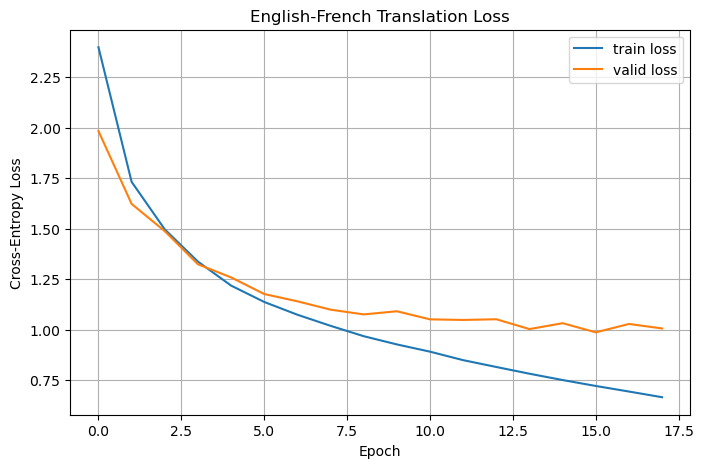

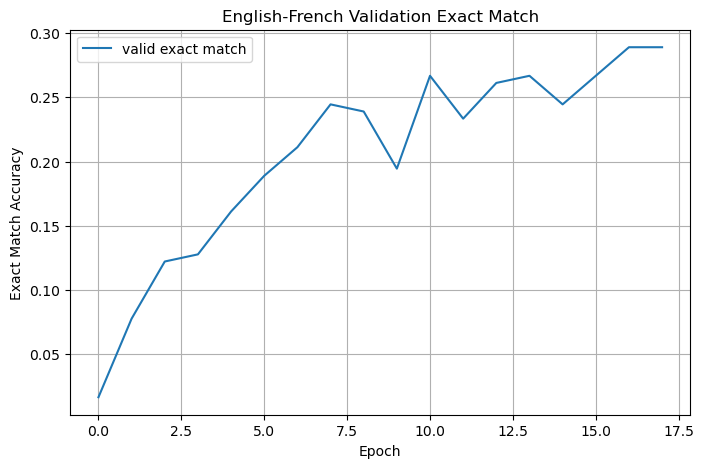

In [19]:

plt.figure(figsize=(8, 5))
plt.plot(translation_history["train_loss"], label="train loss")
plt.plot(translation_history["valid_loss"], label="valid loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("English-French Translation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(translation_history["valid_accuracy"], label="valid exact match")
plt.xlabel("Epoch")
plt.ylabel("Exact Match Accuracy")
plt.title("English-French Validation Exact Match")
plt.legend()
plt.grid(True)
plt.show()



## 13.4 翻譯測試函式

`translate_english_to_french` 會：

1. 文字正規化英文句子。
2. 斷詞／tokenization。
3. 轉成 id。
4. 呼叫 greedy decoding。
5. 把輸出 id 轉回法文 token。

若輸入 token 不在 詞彙表（vocabulary） 裡，會被轉成 `<UNK>`。


In [20]:

def decode_translation_ids(ids, id_to_token):
    tokens = []

    for token_id in ids:
        token = id_to_token[int(token_id)]

        if token == "<EOS>":
            break

        if token not in ["<PAD>", "<SOS>"]:
            tokens.append(token)

    return tokens

def translate_english_to_french(params, sentence, token_to_id, id_to_token, max_len=12):
    src_tokens = tokenize_sentence(sentence)
    src_ids = encode_translation_tokens(src_tokens, token_to_id)

    if len(src_ids) == 0:
        return [], [], []

    pred_ids, attentions = predict(params, src_ids, max_len=max_len)
    pred_tokens = decode_translation_ids(pred_ids, id_to_token)

    return src_tokens, pred_tokens, attentions

def pretty_detokenize(tokens):
    text = " ".join(tokens)

    # 還原常見標點前的空白
    text = text.replace(" .", ".")
    text = text.replace(" !", "!")
    text = text.replace(" ?", "?")
    text = text.replace(" ,", ",")
    text = text.replace(" ;", ";")
    text = text.replace(" :", ":")

    # 簡單處理 apostrophe 周圍空白
    text = text.replace(" ' ", "'")
    text = text.replace("' ", "'")

    return text



## 13.5 在測試集上檢查翻譯效果

下面列出測試集中的英文、參考法文，以及模型產生的法文。


In [21]:

for i in range(15):
    src_ids, tgt_ids, src_tokens, tgt_tokens = translation_test_data_full[i]

    predicted_ids, attentions = predict(
        translation_params,
        src_ids,
        max_len=len(tgt_ids) + 3
    )

    predicted_tokens = decode_translation_ids(predicted_ids, id_to_token)

    print("EN input :", pretty_detokenize(src_tokens))
    print("FR target:", pretty_detokenize(tgt_tokens))
    print("FR pred  :", pretty_detokenize(predicted_tokens))
    print("-" * 60)


EN input : i felt safe.
FR target: je me suis senti en sécurité.
FR pred  : je me sens perdu.
------------------------------------------------------------
EN input : i need it.
FR target: j'en ai besoin.
FR pred  : il l'ai.
------------------------------------------------------------
EN input : get out.
FR target: sors.
FR pred  : <UNK>!
------------------------------------------------------------
EN input : can you try?
FR target: pouvez vous essayer?
FR pred  : <UNK> tu <UNK>?
------------------------------------------------------------
EN input : he is busy.
FR target: il a à faire.
FR pred  : il est malade.
------------------------------------------------------------
EN input : i feel bad.
FR target: je me sens mal.
FR pred  : je suis <UNK>.
------------------------------------------------------------
EN input : what's up?
FR target: ça va?
FR pred  : <UNK> vous <UNK>?
------------------------------------------------------------
EN input : she smiled.
FR target: elle a souri.
FR pr


## 13.6 手動輸入英文短句測試

這些句子不一定全部在訓練集中。若句子包含低頻字，可能會出現 `<UNK>` 或翻譯不穩定。


In [22]:

manual_tests = [
    "i am cold",
    "i am hungry",
    "i love you",
    "thank you",
    "good luck",
    "how are you",
    "i need water",
    "tom is here",
    "we are ready",
    "please stop"
]

for sentence in manual_tests:
    src_tokens, pred_tokens, attentions = translate_english_to_french(
        translation_params,
        sentence,
        token_to_id,
        id_to_token,
        max_len=12
    )

    print("EN input :", sentence)
    print("tokens   :", src_tokens)
    print("FR pred  :", pretty_detokenize(pred_tokens))
    print("-" * 60)


EN input : i am cold
tokens   : ['i', 'am', 'cold']
FR pred  : je suis <UNK>?
------------------------------------------------------------
EN input : i am hungry
tokens   : ['i', 'am', 'hungry']
FR pred  : je suis <UNK>?
------------------------------------------------------------
EN input : i love you
tokens   : ['i', 'love', 'you']
FR pred  : je suis <UNK>.
------------------------------------------------------------
EN input : thank you
tokens   : ['thank', 'you']
FR pred  : <UNK>!
------------------------------------------------------------
EN input : good luck
tokens   : ['good', 'luck']
FR pred  : <UNK> <UNK>!
------------------------------------------------------------
EN input : how are you
tokens   : ['how', 'are', 'you']
FR pred  : <UNK> vous <UNK>?
------------------------------------------------------------
EN input : i need water
tokens   : ['i', 'need', 'water']
FR pred  : j'est du <UNK>?
------------------------------------------------------------
EN input : tom is here



## 13.7 翻譯 attention 權重視覺化

下圖顯示某一句英文測試句在翻譯時的 attention 權重。

- x 軸：英文 source tokens。
- y 軸：模型輸出的法文 target tokens。
- 顏色越深：該 decoder step 越關注該 source token。

翻譯任務不像反轉任務有完美的一對一對齊，但仍可用來觀察模型大致在看哪個英文 token。


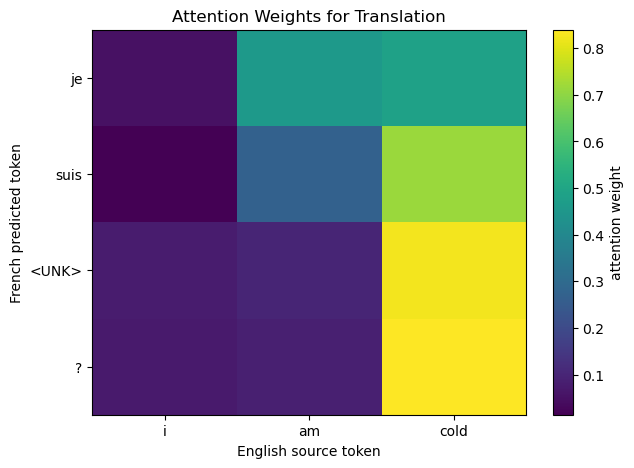

EN input : i am cold
FR pred  : je suis <UNK>?


In [23]:

example_sentence = "i am cold"

src_tokens, pred_tokens, attentions = translate_english_to_french(
    translation_params,
    example_sentence,
    token_to_id,
    id_to_token,
    max_len=12
)

attention_matrix = np.array(attentions)

if len(pred_tokens) > 0 and attention_matrix.shape[0] > 0:
    plt.figure(figsize=(7, 5))
    plt.imshow(attention_matrix[:len(pred_tokens), :], aspect="auto")
    plt.colorbar(label="attention weight")
    plt.xticks(range(len(src_tokens)), src_tokens)
    plt.yticks(range(len(pred_tokens)), pred_tokens)
    plt.xlabel("English source token")
    plt.ylabel("French predicted token")
    plt.title("Attention Weights for Translation")
    plt.show()

print("EN input :", example_sentence)
print("FR pred  :", pretty_detokenize(pred_tokens))
